# 03 — Beyond one pair: commodity baskets and a portfolio of pairs

A single corn–soybean spread is exposed to idiosyncratic breakdowns of that one relation. We add **wheat** and
**cotton** and try two ways of exploiting the wider universe:

1. **Cointegrated baskets** (Johansen). Test which 3- and 4-commodity baskets are cointegrated, then trade the basket
   spread with the same z-score rules as in notebook 02:
   * **Strategy C** — price levels, rolling Johansen eigenvector (252 days), for all five baskets;
   * **Strategy D** — the 4-commodity basket in log prices, with the three hedge estimators of notebook 02
     (static Johansen, Kalman, rolling Johansen).
2. **A portfolio of pairs** (Lee, Leung & Ning, 2023). Trade all six pairs with a z-score rule and allocate capital
   across them according to how mean-reverting each spread currently looks (fitted Ornstein–Uhlenbeck process):
   equal weight (EW), Mean-Reversion Budgeting (MRB) or Mean-Reversion Ranking (MRR) — **Strategy E**.

Data: ETFs SOYB, CORN, WEAT, COTN on common trading days, 2011–2026. As in notebook 02, every parameter is chosen
on the first 70% of the sample and evaluated once on the remaining 30%.

In [1]:
import sys
sys.path.insert(0, '..')
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_etf_prices, train_test_split_date, save_figure, save_table
from src.cointegration import johansen_test, half_life, rolling_johansen, kalman_regression
from src.backtest import (rolling_zscore, log_to_units, zscore_strategy, split_performance)
from src.multipairs import tune_on_dev, evaluate_holdout

prices = load_etf_prices(('soybean', 'corn', 'wheat', 'cotton'))    # columns SOYB, CORN, WEAT, COTN
logp = np.log(prices)
TEST_START = train_test_split_date(prices.index, train_frac=0.7)
train = prices.index < TEST_START
print(f'Train: {prices.index[0].date()} to {prices.index[train][-1].date()} ({train.sum()} days)')
print(f'Test:  {TEST_START.date()} to {prices.index[-1].date()} ({(~train).sum()} days)')

ENTRY_GRID = [1.0, 1.5, 2.0, 2.5, 3.0]

def summarize(ret, pos):
    perf = split_performance(ret, pos, TEST_START)
    return {'train Sharpe': perf.loc['train', 'Sharpe'], 'test Sharpe': perf.loc['test', 'Sharpe'],
            **{k: perf.loc['test', k] for k in ['Ann. return', 'Ann. vol', 'Total return', 'Max drawdown', 'Trades']}}

Train: 2011-09-19 to 2021-11-23 (2522 days)
Test:  2021-11-24 to 2026-04-23 (1082 days)


## 1. Which baskets are cointegrated? (training sample)

Johansen trace test (constant, one lag) of "no cointegrating vector" (r ≤ 0) and the half-life of the static
first-eigenvector portfolio.

In [2]:
BASKETS = {
    'SOYB+CORN+WEAT+COTN': ['SOYB', 'CORN', 'WEAT', 'COTN'],
    'SOYB+CORN+WEAT':      ['SOYB', 'CORN', 'WEAT'],
    'SOYB+CORN+COTN':      ['SOYB', 'CORN', 'COTN'],
    'CORN+WEAT+COTN':      ['CORN', 'WEAT', 'COTN'],
    'SOYB+WEAT+COTN':      ['SOYB', 'WEAT', 'COTN'],
}

rows = {}
for name, assets in BASKETS.items():
    for space, data in [('price', prices), ('log', logp)]:
        table, evec = johansen_test(data.loc[train, assets])
        rows[(name, space)] = {
            'trace': table.loc['r<=0', 'trace'], '95% crit.': table.loc['r<=0', 'trace 95%'],
            'cointegrated (95%)': table.loc['r<=0', 'trace'] > table.loc['r<=0', 'trace 95%'],
            'half-life': half_life((data.loc[train, assets] @ evec[:, 0])),
        }
johansen_tests = pd.DataFrame(rows).T
save_table(johansen_tests, '03_johansen_tests')
johansen_tests

trace 95% crit. cointegrated (95%)  half-life
SOYB+CORN+WEAT+COTN price  49.769549   47.8545               True  34.683587
                    log    43.686935   47.8545              False  47.736611
SOYB+CORN+WEAT      price  34.478884   29.7961               True  32.638668
                    log    26.780735   29.7961              False  50.483402
SOYB+CORN+COTN      price  21.493393   29.7961              False   70.34335
                    log    25.225716   29.7961              False  70.066376
CORN+WEAT+COTN      price  37.683153   29.7961               True  37.734702
                    log    26.198622   29.7961              False  49.198629
SOYB+WEAT+COTN      price   25.35376   29.7961              False  73.552196
                    log    25.748117   29.7961              False  66.855527

In price levels three baskets pass the trace test at 95% (all four commodities, soybean–corn–wheat and
corn–wheat–cotton); in log prices none does. Where cointegration holds, the half-life of the static basket is
about 1.5 months — half that of the corn–soybean pair.

## 2. Strategy C — rolling Johansen baskets (price levels)

The first Johansen eigenvector is re-estimated every day on the previous 252 days and used both as the spread
weights and as the hedge (in units); the z-score also uses 252 days. The entry threshold is chosen per basket on the
training sample.

In [3]:
LOOKBACK = 252
basket_runs, rows = {}, {}
for name, assets in BASKETS.items():
    px = prices[assets]
    w = rolling_johansen(px, window=LOOKBACK)                 # sign-normalised eigenvector
    z = rolling_zscore((w * px).sum(axis=1, min_count=len(assets)), LOOKBACK)
    train_sharpe = {e: split_performance(*zscore_strategy(px, w, z, e), TEST_START).loc['train', 'Sharpe']
                    for e in ENTRY_GRID}
    entry = max(train_sharpe, key=train_sharpe.get)
    basket_runs[name] = zscore_strategy(px, w, z, entry)
    rows[f'C  {name}'] = {'entry': entry, **summarize(*basket_runs[name])}

results_C = pd.DataFrame(rows).T
results_C

,entry,train Sharpe,test Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,Trades
C SOYB+CORN+WEAT+COTN,1.0,0.945250,0.348841,0.027951,0.080126,0.112062,-0.118057,47.0
C SOYB+CORN+WEAT,3.0,0.450080,0.010332,0.000678,0.065628,-0.006305,-0.115719,5.0
C SOYB+CORN+COTN,1.0,0.810198,-0.651977,-0.062459,0.095800,-0.250190,-0.320782,15.0
C CORN+WEAT+COTN,1.0,0.142453,-0.245735,-0.028050,0.114147,-0.137807,-0.242593,21.0
C SOYB+WEAT+COTN,1.0,0.975303,0.150137,0.023737,0.158102,0.049430,-0.253169,19.0


## 3. Strategy D — the four-commodity basket in log prices, three hedge estimators

Same construction as strategy B of notebook 02 with soybean as the normalising asset:
$s_t = \log S_t - \sum_j \beta_{j,t} \log P_{j,t} - \alpha_t$ for $j \in$ {corn, wheat, cotton}. The z-score window is the
half-life of the static basket; the entry threshold is chosen on the static basket and reused.

In [4]:
ASSETS = ['SOYB', 'CORN', 'WEAT', 'COTN']
OTHERS = ASSETS[1:]

_, evec = johansen_test(logp.loc[train, ASSETS])
w_static = pd.Series(evec[:, 0] / evec[0, 0], index=ASSETS)          # SOYB = 1
alpha_static = (logp.loc[train, ASSETS] @ w_static).mean()
spread_D1 = logp[ASSETS] @ w_static - alpha_static
Z_WIN = int(round(half_life(spread_D1[train])))
print('Static weights (log):', w_static.round(3).to_dict(), f'| z-window = half-life = {Z_WIN} days')

def log_units(weights):
    return log_to_units(weights, prices[ASSETS])

units_D1 = log_units(pd.DataFrame([w_static] * len(prices), index=prices.index))
z_D1 = rolling_zscore(spread_D1, Z_WIN)
train_sharpe = {e: split_performance(*zscore_strategy(prices[ASSETS], units_D1, z_D1, e), TEST_START).loc['train', 'Sharpe']
                for e in ENTRY_GRID}
ENTRY_D = max(train_sharpe, key=train_sharpe.get)
print(f'Entry threshold chosen on the training sample: {ENTRY_D}')

Static weights (log): {'SOYB': 1.0, 'CORN': -4.778, 'WEAT': 3.384, 'COTN': 0.954} | z-window = half-life = 48 days
Entry threshold chosen on the training sample: 3.0


In [5]:
# D2: Kalman filter with random-walk coefficients on corn, wheat, cotton and an intercept
X_kf = logp[OTHERS].assign(const=1.0)
state_init = list(-w_static[OTHERS]) + [alpha_static]

def kalman_basket(delta, obs_cov):
    b = kalman_regression(logp['SOYB'], X_kf, delta=delta, obs_cov=obs_cov, state_init=state_init)
    weights = pd.concat([pd.Series(1.0, index=prices.index, name='SOYB'), -b[OTHERS]], axis=1)
    spread = (weights * logp[ASSETS]).sum(axis=1) - b['const']
    return spread, weights

rows = []
for delta in [1e-7, 1e-6, 1e-5, 1e-4]:
    for obs_cov in [1e-3, 1e-2, 1e-1, 1.0]:
        spread, weights = kalman_basket(delta, obs_cov)
        sharpe = split_performance(*zscore_strategy(prices[ASSETS], log_units(weights),
                                                    rolling_zscore(spread, Z_WIN), ENTRY_D),
                                   TEST_START).loc['train', 'Sharpe']
        rows.append({'delta': delta, 'obs_cov': obs_cov, 'train Sharpe': sharpe})
grid_D2 = pd.DataFrame(rows).sort_values('train Sharpe', ascending=False)
DELTA, OBS_COV = grid_D2.iloc[0][['delta', 'obs_cov']]
print(f'Chosen on training sample: delta={DELTA:.0e}, obs_cov={OBS_COV}')

Chosen on training sample: delta=1e-04, obs_cov=1.0


In [6]:
# D3: rolling Johansen in logs, normalised on soybean; trade only if all hedge ratios were within [-2, 2] yesterday
rows, rolling = [], {}
for window in [50, 126, 252]:
    weights = rolling_johansen(logp[ASSETS], window=window, normalize_on='SOYB')
    alpha = (weights * logp[ASSETS].rolling(window).mean().shift(1)).sum(axis=1, min_count=4)
    spread = (weights * logp[ASSETS]).sum(axis=1, min_count=4) - alpha
    allowed = (weights[OTHERS].abs() <= 2).all(axis=1).where(weights.notna().all(axis=1)).shift(1)
    rolling[window] = (spread, weights, allowed)
    sharpe = split_performance(*zscore_strategy(prices[ASSETS], log_units(weights), rolling_zscore(spread, Z_WIN),
                                                ENTRY_D, allowed=allowed), TEST_START).loc['train', 'Sharpe']
    rows.append({'window': window, 'train Sharpe': sharpe})
grid_D3 = pd.DataFrame(rows).sort_values('train Sharpe', ascending=False)
WINDOW_D3 = int(grid_D3.iloc[0]['window'])
print(f'Rolling window chosen on training sample: {WINDOW_D3}')
grid_D3

Rolling window chosen on training sample: 252


,window,train Sharpe
2,252,0.630706
1,126,-0.164044
0,50,-0.356495


In [7]:
spread_D2, weights_D2 = kalman_basket(DELTA, OBS_COV)
spread_D3, weights_D3, allowed_D3 = rolling[WINDOW_D3]

log_runs = {
    'D1 log, static Johansen':  zscore_strategy(prices[ASSETS], units_D1, z_D1, ENTRY_D),
    'D2 log, Kalman':           zscore_strategy(prices[ASSETS], log_units(weights_D2),
                                                rolling_zscore(spread_D2, Z_WIN), ENTRY_D),
    'D3 log, rolling Johansen': zscore_strategy(prices[ASSETS], log_units(weights_D3),
                                                rolling_zscore(spread_D3, Z_WIN), ENTRY_D, allowed=allowed_D3),
}
results_D = pd.DataFrame({name: {'entry': ENTRY_D, **summarize(*run)} for name, run in log_runs.items()}).T
results_basket = pd.concat([results_C, results_D])
save_table(results_basket, '03_basket_strategies')
results_basket.round(3)

,entry,train Sharpe,test Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,Trades
C SOYB+CORN+WEAT+COTN,1.0,0.945,0.349,0.028,0.080,0.112,-0.118,47.0
C SOYB+CORN+WEAT,3.0,0.450,0.010,0.001,0.066,-0.006,-0.116,5.0
C SOYB+CORN+COTN,1.0,0.810,-0.652,-0.062,0.096,-0.250,-0.321,15.0
C CORN+WEAT+COTN,1.0,0.142,-0.246,-0.028,0.114,-0.138,-0.243,21.0
C SOYB+WEAT+COTN,1.0,0.975,0.150,0.024,0.158,0.049,-0.253,19.0
"D1 log, static Johansen",3.0,0.810,-0.026,-0.002,0.060,-0.014,-0.104,8.0
"D2 log, Kalman",3.0,0.770,-0.152,-0.009,0.058,-0.044,-0.109,10.0
"D3 log, rolling Johansen",3.0,0.631,-0.282,-0.018,0.065,-0.085,-0.162,21.0


## 4. Strategy E — a portfolio of six pairs with OU-based capital allocation

For each of the six pairs, a rolling-OLS spread is traded with a z-score rule (entry at $K$ standard deviations of
the last 63 days, exit at the mean, hedge frozen at entry). Every `rebal_freq` days all positions are closed and capital
is re-allocated from an Ornstein–Uhlenbeck fit to the last `ou_window` days of each spread:

* **EW** — equal weights;
* **MRB** — weight ∝ (normalised speed of reversion μ/σ) × (normalised OU log-likelihood), pairs with no mean reversion get 0;
* **MRR** — fixed weights by rank of the same score (the best pair gets 3× the worst).

$K$, the OLS window, the rebalancing frequency and the OU window are tuned jointly on the training sample by the
Sharpe ratio of the EW portfolio.

In [8]:
PAIRS = list(combinations(ASSETS, 2))
best_params, dev_table = tune_on_dev(prices[ASSETS], PAIRS, TEST_START, verbose=False)
print('Chosen on the training sample:', best_params)
dev_table.head(5).round(3)

Chosen on the training sample: {'K': 1.0, 'ols_window': 252, 'rebal_freq': 21, 'ou_window': 63}


,K,ols_window,rebal_freq,ou_window,dev_Sharpe
0,1.0,252,21,63,0.378
1,1.0,252,21,252,0.361
2,1.0,252,21,126,0.360
3,1.5,252,21,63,0.349
4,1.5,252,21,252,0.327


In [9]:
ou = evaluate_holdout(prices[ASSETS], PAIRS, best_params, TEST_START)
results_E = ou['table'].rename(index=lambda m: f'E  pairs portfolio, {m}')
save_table(results_E, '03_multipair_ou')
results_E.round(3)

,train Sharpe,test Sharpe,Ann. return,Ann. vol,Max drawdown,Total return
"E pairs portfolio, EW",0.378,0.415,0.035,0.085,-0.152,0.146
"E pairs portfolio, MRB",0.068,0.380,0.032,0.085,-0.160,0.131
"E pairs portfolio, MRR",0.241,0.457,0.037,0.082,-0.148,0.158


## 5. Summary

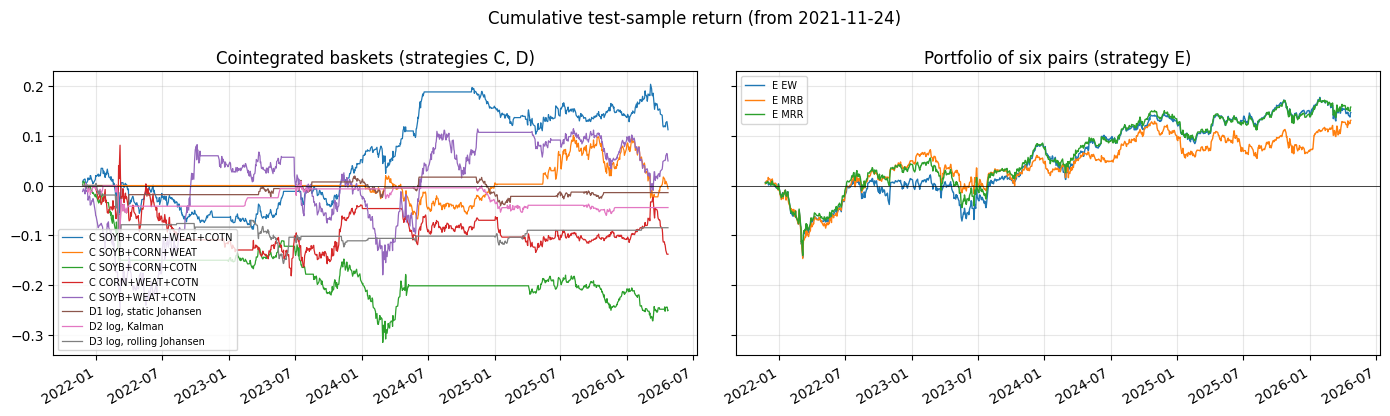

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
def test_equity(ret):
    return (1 + ret[ret.index >= TEST_START]).cumprod() - 1

for name, (ret, _) in {**{f'C {k}': v for k, v in basket_runs.items()}, **log_runs}.items():
    test_equity(ret).plot(ax=axes[0], lw=0.9, label=name)
for method, ret in ou['series'].items():
    test_equity(ret).plot(ax=axes[1], lw=1, label=f'E {method}')
axes[0].set_title('Cointegrated baskets (strategies C, D)')
axes[1].set_title('Portfolio of six pairs (strategy E)')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3); ax.legend(fontsize=7); ax.set_xlabel('')
fig.suptitle(f'Cumulative test-sample return (from {TEST_START.date()})')
plt.tight_layout()
save_figure(fig, 'multi_commodity_test_returns')
plt.show()

**Take-aways.** (See the tables above for the numbers.)
* Formal cointegration on the training sample is a poor guide to out-of-sample profitability: baskets that pass the
  Johansen test do not systematically do better than those that fail it.
* Adding commodities shortens the half-life, but the extra hedge ratios are estimated with more noise; rolling and
  Kalman estimates in particular produce unstable weights.
* The portfolio of pairs diversifies the idiosyncratic risk of a single spread, but all four markets share the same
  drivers (weather, feed and energy demand), so the pairs are strongly correlated and the OU-based allocation has
  little cross-sectional information to exploit.
* The first version of the pairs portfolio reported a Sharpe ratio of about 1.6. That figure came from P&L measured
  in units of spread standard deviations (not capital) and from parameters chosen on the full sample; with
  capital-normalised, frozen-hedge P&L and a proper train/test split the results are in the tables above.